## Import Modules

In [24]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pyvista as pv



## Load data

This code expects the input files to have the following dimensions: $(n model, x_{idx}, y_{idx}, z_{idx})$. Values are the property being analysed.


In [ ]:
# load data
path_to_data = '{path_to_your_data}'  # Replace with your actual path

ensemble_tensor = np.load(path_to_data)  # Example data, replace with actual data loading logic

n_m, nx, ny, nz = ensemble_tensor.shape

# Flatten the tensor to a 2D array for PCA
# New shape will be (n_m, nx*ny*nz)
X = ensemble_tensor.reshape(n_m, -1)

## plot a model

Using pyvista, select a model and plot it in 3D

In [26]:
model_to_display = 57

# Get dimension sizes from ensemble_list
ensemble_shape = ensemble_tensor.shape
print(f"Full ensemble_list shape: {ensemble_shape}")


# Create a list of dimension sizes
dimension_list = [n_m, nx, ny, nz]
print(f"Dimension list: {dimension_list}")

model_plot = ensemble_tensor[model_to_display]

#values = model_plot[:, 3].reshape((nx, ny, nz), order = 'F')

Full ensemble_list shape: (125, 30, 70, 30)
Dimension list: [125, 30, 70, 30]


In [28]:
# Extract property values and reshape to 3D grid
values = model_plot.reshape((nx, ny, nz), order='F')

# Create a pyvista structured grid
# Create coordinate arrays for the grid
x = np.arange(nx)
y = np.arange(ny)
z = np.arange(nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Create structured grid
grid = pv.StructuredGrid(X, Y, -Z)
grid['density'] = values.flatten(order='F')

# Plot in 3D
plotter = pv.Plotter()
plotter.add_mesh(grid, scalars='density', cmap='viridis', opacity=0.7)
plotter.add_mesh(grid)
plotter.show()
plotter.add_title(f'Model {model_to_display} Density Plot')

/Users/lin236/Environments/Loop/lib/python3.12/site-packages/pyvista/core/utilities/points.py:55: UserWarning:

Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.



Widget(value='<iframe src="http://localhost:53870/index.html?ui=P_0x131bf9ac0_1&reconnect=auto" class="pyvista…

<CornerAnnotation(0xc2660dc00) at 0x12dde2ec0>

## Calculate diversity metrics for each model

The metrics are statistical, geometrical and topological; 
### Statistical
* average density for each model
* variance
* skew
* minimum
* maximum

### Geometrical
* centre of mass: the location of the 
* orientation and stretch of a density mass

### Topological 

* Global Moran's I - spatial autocorrelation, how clumpy the density distribution is

```math
I = {N \over S_0} {\sum{_i} \sum{_j} w_{ij} (z_i)(z_j) \over \sum_i z^2_i}
```
Where:

* $N$ is the total number of voxels.
* $z_i = (\rho_i - \bar{\rho})$ is the deviation of density at voxel i for the mean density $\bar{\rho}$.
* $w{_ij}$ are the spatial weights indicating connectivity (= 1 if voxels are neighbours, = 0 otherwise).
* $S_0 = \sum{_i} \sum{_j} w_{ij} $ is the sum of all weights.

### Possible additions
* volume of high or low density zones (above or below a threshold)
* semi-variogram parameters



## Define functions

In [ ]:
# define function to calculate Moran's I for 3D data

from scipy.ndimage import convolve

def calculate_morans_i_3d(model_3d):
    """
    model_3d: 3D numpy array (x, y, z) representing density
    """
    # 1. Mean-center the density values
    z = model_3d - np.mean(model_3d)
    
    # 2. Define the neighborhood kernel (6-neighbor Rook contiguity)
    # This kernel sums the values of the 6 immediate face-sharing neighbors
    kernel = np.array([
        [[0, 0, 0], [0, 1, 0], [0, 0, 0]],
        [[0, 1, 0], [1, 0, 1], [0, 1, 0]],
        [[0, 0, 0], [0, 1, 0], [0, 0, 0]]
    ])
    
    # 3. Calculate Spatial Lag using convolution
    # lag_i = sum of neighbors' z-values
    z_lag = convolve(z, kernel, mode='constant', cval=0.0)
    
    # 4. Compute Moran's I components
    N = model_3d.size
    S0 = np.sum(convolve(np.ones_like(z), kernel, mode='constant', cval=0.0))
    
    numerator = N * np.sum(z * z_lag)
    denominator = S0 * np.sum(z**2)
    
    return numerator / denominator

In [33]:
# define function to extract metrics from 4D ensemble tensor

def extract_metrics_4d(ensemble):
    """
    ensemble: np.array of shape (n_models, x_dim, y_dim, z_dim)
    Values are density.
    """
    n_models, nx, ny, nz = ensemble.shape
    
    # Create coordinate grids once (x, y, z indices for every voxel)
    # This represents the "location" of each density value
    x_idx, y_idx, z_idx = np.indices((nx, ny, nz))
    coords = np.stack([x_idx, y_idx, z_idx], axis=-1) # Shape: (nx, ny, nz, 3)

    metrics_list = []

    for i in range(n_models):
        rho = ensemble[i]
        total_rho = np.sum(rho)
        
        # 1. Statistical Metrics
        m_rho = np.mean(rho)
        v_rho = np.var(rho)
        s_rho = skew(rho.flatten())
        
        # 2. Geometric Centroid (Center of Mass in voxel units)
        # We multiply the coordinate grids by the density values
        centroid = np.array([
            np.sum(x_idx * rho) / total_rho,
            np.sum(y_idx * rho) / total_rho,
            np.sum(z_idx * rho) / total_rho
        ])
        
        # 3. Inertia Tensor (Spatial Spread)
        # Shift coords so origin is at the centroid
        rel_coords = coords - centroid
        
        # Flatten for matrix multiplication
        rel_coords_flat = rel_coords.reshape(-1, 3)
        rho_flat = rho.flatten()
        
        # Covariance-like matrix of the density distribution
        inertia_tensor = (rel_coords_flat.T * rho_flat) @ rel_coords_flat / total_rho
        
        # Eigenvalues describe the length of the 3 principal axes of the density mass
        evals = np.linalg.eigvals(inertia_tensor)
        evals = np.sort(evals)[::-1]
        
        # Moran's I for spatial autocorrelation
        morans_i = calculate_morans_i_3d(rho)

        metrics_list.append({
            'model_index': i,
            'mean_rho': m_rho,
            'var_rho': v_rho,
            'skew_rho': s_rho,
            'centroid_z': centroid[2],  # Depth of the anomaly
            'axis_major': evals[0],     # Primary elongation
            'sphericity': evals[2] / evals[0] if evals[0] > 0 else 0,
            'max_rho': np.max(rho),
            'min_rho': np.min(rho),
            'morans_i': morans_i
        })

    return pd.DataFrame(metrics_list).set_index('model_index')

## PCA & Hotelling’s T2 Implementation

This section takes the geodiversity metrics and performs the multivariate outlier detection.


In [35]:
# define function to perform PCA and calculate Hotelling's T^2

def analyze_ensemble_pca(features_df):
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features_df)
    
    # PCA
    pca = PCA()
    scores = pca.fit_transform(X_scaled)
    
    # Hotelling's T^2 calculation
    # Normalized distance of each model from the ensemble mean
    ev = pca.explained_variance_
    t2 = np.sum((scores**2) / ev, axis=1)
    
    results = features_df.copy()
    results['PC1'] = scores[:, 0]
    results['PC2'] = scores[:, 1]
    results['T2'] = t2
    
    return results, scores, pca,



## Execute functions
* extract metrics
* run the PCA

In [36]:
# Usage:
features = extract_metrics_4d(ensemble_tensor)
final_df, scores, pca_obj = analyze_ensemble_pca(features)

## Visualise results

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# define function to plot PCA results with scree plot and biplot

def plot_pca_results(pca, scores, feature_names):
    """
    pca: The fitted sklearn PCA object
    scores: The transformed PCA scores (PCA.transform(X))
    feature_names: list of metric names (e.g., features_df.columns)
    """
    
    # Scree Plot
    plt.figure(figsize=(8, 5))
    exp_var = pca.explained_variance_ratio_
    cum_var = np.cumsum(exp_var)
    
    plt.bar(range(1, len(exp_var)+1), exp_var, alpha=0.5, align='center', label='Individual variance')
    plt.step(range(1, len(cum_var)+1), cum_var, where='mid', label='Cumulative variance')
    
    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal component index')
    plt.title('Scree Plot: Variance per Component')
    plt.legend(loc='best')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # PCA Biplot
    plt.figure(figsize=(10, 8))
    
    # Plot the models as scores
    sns.scatterplot(x=scores[:, 0], y=scores[:, 1], alpha=0.6, s=60, edgecolors='w')
    
    # Determine scale for loading arrows
    # Arrows are scaled so they fit comfortably within the scores plot
    scale_factor = np.max(np.abs(scores[:, 0:2])) / np.max(np.abs(pca.components_[0:2, :])) * 0.8
    
    # Plot loading vectors
    for i, name in enumerate(feature_names):
        # Coordinates for the arrow (PC1 loading, PC2 loading)
        x = pca.components_[0, i] * scale_factor
        y = pca.components_[1, i] * scale_factor
        
        plt.arrow(0, 0, x, y, color='red', alpha=0.8, head_width=0.15, lw=1.5)
        plt.text(x * 1.1, y * 1.1, name, color='darkred', ha='center', va='center', fontweight='bold')

    plt.axhline(0, color='black', linewidth=1, alpha=0.3)
    plt.axvline(0, color='black', linewidth=1, alpha=0.3)
    plt.xlabel(f'PC1 ({exp_var[0]:.1%} variance)')
    plt.ylabel(f'PC2 ({exp_var[1]:.1%} variance)')
    plt.title('PCA Biplot: Models (Dots) vs. Metrics (Vectors)')
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()



## Execute visualisation

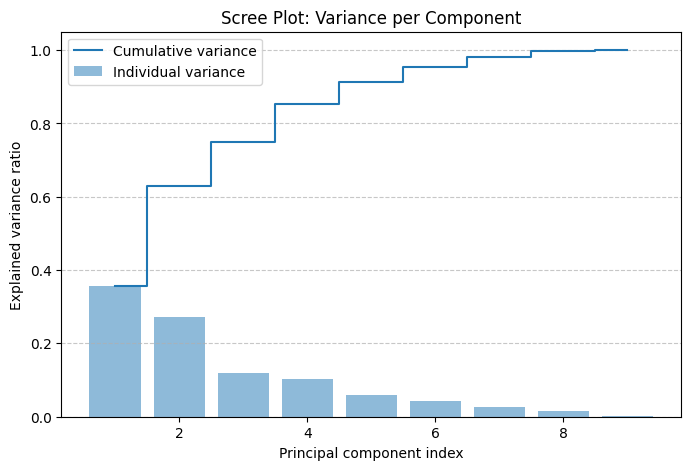

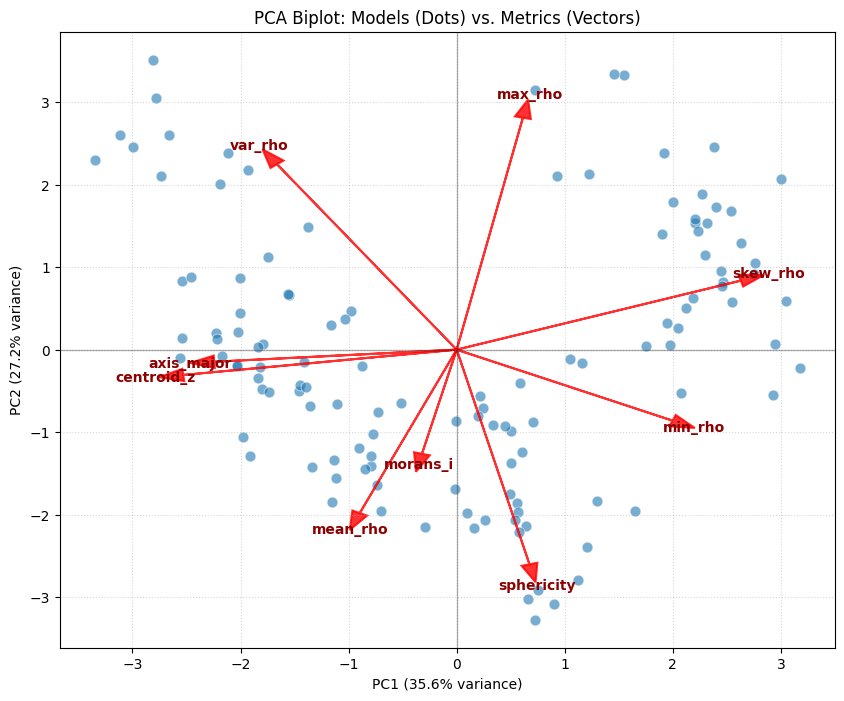

In [40]:
plot_pca_results(pca_obj, scores[:,:2], features.columns) # scores[:,:2] are the coordinates of each model in the PC1-PC2 space, features.columns are the metric names for the loading vectors

## PCA and Hotelling’s T2 Calculation

Hotelling's $T^2$ score identifies outliers by measuring the multivariate distance from the centre of the ensemble. For this case, the multivariates are the geodiversity metrics.

The T2 statistic for a model realization i in the PCA space is calculated as:
```math
T^2​ = n(\bar{x} - \mu)'S^-1(\bar{x} - \mu)
```
Where
* $n$ is the number of samples (inversion models in this case)
* $S^-1$ is the inverse covariance matrix.
* $(\bar{x} - \mu)$ is the distance from the mean

The interpretation is that a model with a high $T^2$ score is unique when compared to the rest of the models as characterised by the geodiversity metrics. The following control charts plot all the models and their distance from the multivariate centre of the ensemble. Outliers are defined as exceeding a predefined significance level. 

The significance default is 95% limit, however can be changed by passing a different value to the 'alpha' argument in the plot_t2_control_chart function.
* 95% limit is $\alpha$ = 0.05 , $(1 - limit)$
* e.g. $limit$ = 80%, $1 - .8 = 0.2$


In [ ]:
# define function to plot Hotelling's T^2 control chart using matplot lib

from scipy.stats import f

def plot_t2_control_chart(t2_values, n_samples, p_features, alpha=0.05):
    """
    t2_values: Array of T2 scores
    n_samples: Number of models (rows)
    p_features: Number of metrics (columns)
    alpha: Significance level (0.05 for 95% limit)
    """
    # Calculate the F-distribution threshold
    # Formula: ((n-1)*p / (n-p)) * F_alpha(p, n-p)
    f_threshold = f.ppf(1 - alpha, p_features, n_samples - p_features)
    threshold = (p_features * (n_samples - 1) / (n_samples - p_features)) * f_threshold

    plt.figure(figsize=(10, 5))
    plt.stem(range(len(t2_values)), t2_values, markerfmt='o', basefmt=" ")
    plt.axhline(threshold, color='red', linestyle='--', label=f'{int((1-alpha)*100)}% Confidence Limit')
    
    # Highlight outliers
    outliers = np.where(t2_values > threshold)[0]
    plt.scatter(outliers, t2_values[outliers], color='red', s=100, zorder=5)

    plt.xlabel('Model Index')
    plt.ylabel('Hotelling\'s $T^2$ Value')
    plt.title('Hotelling\'s $T^2$ Control Chart')
    plt.legend()
    plt.show()

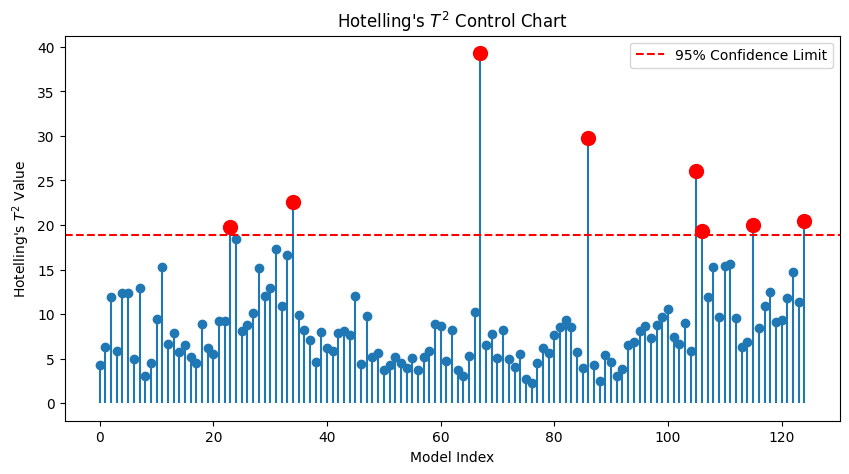

In [21]:
plot_t2_control_chart(final_df['T2'].values, n_samples=final_df.shape[0], p_features=final_df.shape[1]-3, alpha=0.05)

In [41]:
# # define function to plot and interactive Hotelling's T^2 control chart using plotly

import plotly.graph_objects as go
import numpy as np
from scipy.stats import f

def plot_t2_plotly(t2_values, n_samples, p_features, alpha=0.05):
    """
    t2_values: Array of T2 scores from your PCA
    n_samples: Number of models in the ensemble
    p_features: Number of metrics used for PCA
    alpha: Significance level (0.05 for 95% limit)
    """
    # 1. Calculate the Statistical Threshold (Upper Control Limit)
    # Formula: ((n-1)*p / (n-p)) * F_alpha(p, n-p)
    f_val = f.ppf(1 - alpha, p_features, n_samples - p_features)
    ucl = (p_features * (n_samples - 1) / (n_samples - p_features)) * f_val

    # 2. Identify outliers for specialized styling
    is_outlier = t2_values > ucl
    colors = ['#EF553B' if val else '#636EFA' for val in is_outlier]

    # 3. Create the Plotly Figure
    fig = go.Figure()

    # Add the "stems" (vertical lines)
    for i in range(len(t2_values)):
        fig.add_trace(go.Scatter(
            x=[i, i],
            y=[0, t2_values[i]],
            mode='lines',
            line=dict(color='lightgrey', width=1),
            hoverinfo='none',
            showlegend=False
        ))

    # Add the points
    fig.add_trace(go.Scatter(
        x=np.arange(len(t2_values)),
        y=t2_values,
        mode='markers',
        marker=dict(
            color=colors,
            size=10,
            line=dict(width=1, color='DarkSlateGrey')
        ),
        text=[f"Model Index: {i}<br>T² Value: {v:.2f}" for i, v in enumerate(t2_values)],
        hoverinfo='text',
        name='Models'
    ))

    # Add the Threshold Line
    fig.add_shape(
        type="line",
        x0=0, x1=len(t2_values)-1,
        y0=ucl, y1=ucl,
        line=dict(color="Red", width=2, dash="dash"),
    )

    # Add annotation for the threshold
    fig.add_annotation(
        x=len(t2_values)-1,
        y=ucl,
        text=f"{int((1-alpha)*100)}% Confidence Limit",
        showarrow=False,
        yshift=10,
        font=dict(color="Red")
    )

    # Update layout
    fig.update_layout(
        title=f"Hotelling's T² Control Chart (α={alpha})",
        xaxis_title="Model Index",
        yaxis_title="T² Statistic",
        template="plotly_white",
        hovermode="closest"
    )

    fig.show()

# Example Usage:
# n, p = features_df.shape
# plot_t2_plotly(results['T2'].values, n, p)

In [23]:
plot_t2_plotly(final_df['T2'].values, n_samples=final_df.shape[0], p_features=final_df.shape[1]-3)

4. Interpretation and Visualization

Models with T2>UCL are your "geodiverse" outliers—those that represent the edges of the model space.